# 📊 Exploratory Data Analysis (EDA)
### Metodologi CRISP-DM: Business Understanding & Data Understanding
---
> **Petunjuk Penggunaan:**
> - Ganti semua bagian bertanda `# 🔧 SESUAIKAN` dengan nilai yang sesuai dataset kamu
> - Jalankan sel secara berurutan dari atas ke bawah
> - Setiap blok dikelompokkan sesuai tahapan CRISP-DM

---
## DATA UNDERSTANDING
### Tahap 1 — Import Library

In [ ]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, kstest, normaltest
import warnings

# Library tambahan (aktifkan jika dibutuhkan)
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
# Upload dataset ke github
# Periksa RAW
# Copy link URL RAW pasti ke sini, pastikan beri spasi dari data/

!wget -P data/ https://raw.githubusercontent.com/rizkimshafardataanalyst-design/PPKD-JAKSEL/refs/heads/main/Sales%20Adidas%20US.csv

--2026-08-10 08:39:21--  https://raw.githubusercontent.com/rizkimshafardataanalyst-design/PPKD-JAKSEL/refs/heads/main/Sales%20Adidas%20US.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1163231 (1.1M) [text/plain]
Saving to: ‘data/Sales Adidas US.csv.3’

Sales Adidas US.csv 100%[===================>]   1.11M  --.-KB/s    in 0.05s   

2026-08-10 08:39:21 (21.0 MB/s) - ‘data/Sales Adidas US.csv.3’ saved [1163231/1163231]



In [ ]:
# ============================================================
# 2. IMPORT DATASET
# ============================================================

# Membaca file sesuai format
df = pd.read_csv('data/Sales Adidas US.csv', sep=";")
# df = pd.read_excel(FILE_PATH, sheet_name='Sheet1')             # Excel  # 🔧 sesuaikan sheet_name

print("✅ Dataset berhasil diload!")
print(f"   Jumlah baris    : {df.shape[0]:,}")
print(f"   Jumlah kolom    : {df.shape[1]:,}")

✅ Dataset berhasil diload!
   Jumlah baris    : 9,648
   Jumlah kolom    : 14


In [ ]:
# ============================================================
# 3. MEMBACA DATASET — Gambaran Awal
# ============================================================

df

,Retailer,Transaction ID,Invoice Date,Region,State,City,Product,Product ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,IT0001,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF33,"$34,00",384,13056,"6789,12","0,52",Outlet
1,Foot Locker,IT0002,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF52,"$47,00",336,15792,"9633,12","0,61",Online
2,Foot Locker,IT0003,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF56,"$50,00",1200,600000,300000,"0,5",In-store
3,Foot Locker,IT0004,01/01/2020,Northeast,Pennsylvania,Philadelphia,Women's Apparel,WA58,"$53,00",83,4399,"1407,68","0,32",Outlet
4,Foot Locker,IT0005,01/01/2020,Northeast,Pennsylvania,Philadelphia,Women's Apparel,WA80,"$68,00",83,5644,"2426,92","0,43",Online
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,IT9644,31/12/2021,Northeast,Pennsylvania,Philadelphia,Men's Apparel,MA38,"$46,00",56,2576,"1004,64","0,39",Outlet
9644,Amazon,IT9645,31/12/2021,Northeast,Maine,Portland,Men's Apparel,MA46,"$52,00",36,1872,"692,64","0,37",Online
9645,Amazon,IT9646,31/12/2021,Northeast,Maine,Portland,Men's Apparel,MA49,"$55,00",125,68750,"17187,5","0,25",Outlet
9646,Foot Locker,IT9647,31/12/2021,Northeast,Pennsylvania,Philadelphia,Men's Apparel,MA60,"$63,00",47,2961,"1362,06","0,46",Online


In [ ]:
# ============================================================
# 4. df.info() — Tipe Data & Non-Null Count
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Transaction ID    9648 non-null   object
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Product ID        9648 non-null   object
 8    Price per Unit   9648 non-null   object
 9   Units Sold        9648 non-null   int64 
 10  Total Sales       9648 non-null   int64 
 11  Operating Profit  9648 non-null   object
 12  Operating Margin  9648 non-null   object
 13  Sales Method      9648 non-null   object
dtypes: int64(2), object(12)
memory usage: 1.0+ MB


In [ ]:
# ============================================================
# 5. df.shape — Dimensi Dataset
# ============================================================

baris, kolom = df.shape
print(f"📐 Dimensi Dataset : {baris:,} baris  ×  {kolom} kolom")

📐 Dimensi Dataset : 9,648 baris  ×  14 kolom


In [ ]:
# ============================================================
# 6. META DATASET - Kamus Fitur
# ============================================================

# 🔧 SESUAIKAN: Isi penjelasan dan fungsi setiap fitur dataset kamu
meta = pd.DataFrame({
    'Nama Fitur': [
       'Retailer', 'Transaction ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Product ID', ' Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'
    ],
    'Penjelasan': [
        'Nama pengecer tempat penjualan terjadi.',
        'Pengidentifikasi unik untuk setiap transaksi.',
        'Tanggal transaksi dilakukan.',
        'Wilayah geografis tempat penjualan.',
        'Negara bagian tempat penjualan dilakukan.',
        'Kota tempat penjualan dilakukan.',
        'Kategori produk yang dijual (misalnya, Pakaian Pria, Alas Kaki Jalanan Pria).',
        'Pengidentifikasi unik untuk setiap produk.',
        'Harga satu unit produk.',
        'Jumlah unit yang terjual dalam transaksi.',
        'Total pendapatan dari transaksi.',
        'Keuntungan yang dihasilkan dari transaksi setelah dikurangi biaya operasional.',
        'Margin operasi sebagai persentase dari total penjualan, menunjukkan efisiensi.',
        'Metode penjualan (misalnya, Outlet, Online, In-store).'
    ],
    'Fungsi dalam Analisis': [
        'Fitur kategorikal untuk analisis kinerja penjualan per pengecer.',
        'Pengidentifikasi unik, bukan untuk analisis langsung.',
        'Fitur temporal untuk analisis deret waktu dan tren.',
        'Fitur kategorikal untuk analisis geografis.',
        'Fitur kategorikal untuk analisis geografis yang lebih granular.',
        'Fitur kategorikal untuk analisis geografis yang sangat granular.',
        'Fitur kategorikal untuk analisis kinerja produk.',
        'Fitur kategorikal untuk pelacakan produk tertentu.',
        'Fitur numerik untuk analisis strategi harga.',
        'Fitur numerik untuk analisis volume penjualan.',
        'Fitur numerik untuk analisis pendapatan, indikator kinerja utama.',
        'Fitur numerik untuk analisis profitabilitas.',
        'Fitur numerik untuk analisis rasio efisiensi dan profitabilitas.',
        'Fitur kategorikal untuk analisis kinerja saluran penjualan.'
    ]
})

display(meta.style.set_properties(**{'text-align': 'left'})
             .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

,Nama Fitur,Penjelasan,Fungsi dalam Analisis
0,Retailer,Nama pengecer tempat penjualan terjadi.,Fitur kategorikal untuk analisis kinerja penjualan per pengecer.
1,Transaction ID,Pengidentifikasi unik untuk setiap transaksi.,"Pengidentifikasi unik, bukan untuk analisis langsung."
2,Invoice Date,Tanggal transaksi dilakukan.,Fitur temporal untuk analisis deret waktu dan tren.
3,Region,Wilayah geografis tempat penjualan.,Fitur kategorikal untuk analisis geografis.
4,State,Negara bagian tempat penjualan dilakukan.,Fitur kategorikal untuk analisis geografis yang lebih granular.
5,City,Kota tempat penjualan dilakukan.,Fitur kategorikal untuk analisis geografis yang sangat granular.
6,Product,"Kategori produk yang dijual (misalnya, Pakaian Pria, Alas Kaki Jalanan Pria).",Fitur kategorikal untuk analisis kinerja produk.
7,Product ID,Pengidentifikasi unik untuk setiap produk.,Fitur kategorikal untuk pelacakan produk tertentu.
8,Price per Unit,Harga satu unit produk.,Fitur numerik untuk analisis strategi harga.
9,Units Sold,Jumlah unit yang terjual dalam transaksi.,Fitur numerik untuk analisis volume penjualan.


In [ ]:
# ============================================================
# 7. MENAMPILKAN 5 DATA TERATAS
# ============================================================

print("5 Data Teratas:")
df.head()

5 Data Teratas:


,Retailer,Transaction ID,Invoice Date,Region,State,City,Product,Product ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,IT0001,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF33,"$34,00",384,13056,"6789,12","0,52",Outlet
1,Foot Locker,IT0002,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF52,"$47,00",336,15792,"9633,12","0,61",Online
2,Foot Locker,IT0003,01/01/2020,Northeast,New York,New York,Men's Street Footwear,MSF56,"$50,00",1200,600000,300000,"0,5",In-store
3,Foot Locker,IT0004,01/01/2020,Northeast,Pennsylvania,Philadelphia,Women's Apparel,WA58,"$53,00",83,4399,"1407,68","0,32",Outlet
4,Foot Locker,IT0005,01/01/2020,Northeast,Pennsylvania,Philadelphia,Women's Apparel,WA80,"$68,00",83,5644,"2426,92","0,43",Online


In [ ]:
# ============================================================
# 8. MENAMPILKAN 5 DATA TERAKHIR
# ============================================================

print("5 Data Terakhir:")
df.tail()

5 Data Terakhir:


,Retailer,Transaction ID,Invoice Date,Region,State,City,Product,Product ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
9643,Foot Locker,IT9644,31/12/2021,Northeast,Pennsylvania,Philadelphia,Men's Apparel,MA38,"$46,00",56,2576,"1004,64","0,39",Outlet
9644,Amazon,IT9645,31/12/2021,Northeast,Maine,Portland,Men's Apparel,MA46,"$52,00",36,1872,"692,64","0,37",Online
9645,Amazon,IT9646,31/12/2021,Northeast,Maine,Portland,Men's Apparel,MA49,"$55,00",125,68750,"17187,5","0,25",Outlet
9646,Foot Locker,IT9647,31/12/2021,Northeast,Pennsylvania,Philadelphia,Men's Apparel,MA60,"$63,00",47,2961,"1362,06","0,46",Online
9647,Foot Locker,IT9648,31/12/2021,Northeast,Pennsylvania,Philadelphia,Men's Apparel,MA69,"$70,00",175,122500,42875,"0,35",Outlet


In [ ]:
# ============================================================
# 9. KEUNIKAN FITUR KATEGORIKAL
# ============================================================

kolom_kategorikal = ['Retailer', 'Region', 'State','City','Product','Sales Method'] # 🔧 SESUAIKAN: Tambah atau kurangi nama kolom kategorikal
print(f"Kolom kategorikal terdeteksi: {kolom_kategorikal}\\n")

for col in kolom_kategorikal:
    unique_vals = df[col].unique()
    print(f"📌 '{col}' ({df[col].nunique()} nilai unik):")
    print(f"   {unique_vals}")
    print(f"   Value counts:")
    vc = df[col].value_counts().to_string()
    for line in vc.split('\n'):
        print(f"    {line}")
    print()

Kolom kategorikal terdeteksi: ['Retailer', 'Region', 'State', 'City', 'Product', 'Sales Method']\n
📌 'Retailer' (6 nilai unik):
   ['Foot Locker' 'West Gear' 'Walmart' 'Sports Direct' "Kohl's" 'Amazon']
   Value counts:
    Retailer
    Foot Locker      2637
    West Gear        2374
    Sports Direct    2032
    Kohl's           1030
    Amazon            949
    Walmart           626

📌 'Region' (5 nilai unik):
   ['Northeast' 'West' 'Southeast' 'South' 'Midwest']
   Value counts:
    Region
    West         2448
    Northeast    2376
    Midwest      1872
    South        1728
    Southeast    1224

📌 'State' (50 nilai unik):
   ['New York' 'Pennsylvania' 'Nevada' 'Colorado' 'Florida' 'Washington'
 'Texas' 'Minnesota' 'California' 'Montana' 'Iowa' 'Louisiana'
 'North Dakota' 'South Carolina' 'New Jersey' 'Georgia' 'South Dakota'
 'Maine' 'Alaska' 'Connecticut' 'Wisconsin' 'Delaware' 'Missouri' 'Kansas'
 'New Mexico' 'North Carolina' 'Massachusetts' 'Oklahoma' 'Oregon'
 'Hawaii' 'Rho

In [ ]:
# ============================================================
# 10. DESKRIPSI STATISTIK — Fitur Numerikal
# ============================================================
print("Statistik Deskriptif Fitur Numerikal:")
kolom_numerik = df.select_dtypes(include=np.number).columns.tolist()
# kolom_numerik = ['co2_ppm', 'pm25_ugm3', 'humidity_pct']  # 🔧 SESUAIKAN jika mau hanya beberapa kolom numerik

df[kolom_numerik].describe()

Statistik Deskriptif Fitur Numerikal:


,Units Sold,Total Sales
count,9648.0000,9648.0000
mean,256.9300,93273.4375
std,214.2520,141916.0167
min,0.0000,0.0000
25%,106.0000,4254.5000
50%,176.0000,9576.0000
75%,350.0000,150000.0000
max,1275.0000,825000.0000


In [ ]:
# ============================================================
# 11. CEK SKEWNESS (Kemiringan Distribusi)
# ============================================================

print("Interpretasi:")
print("  Skewness ≈ 0        : Distribusi simetris (normal)")
print("  Skewness > +0.5     : Miring kanan (positif skew)")
print("  Skewness < -0.5     : Miring kiri (negatif skew)")
print("  |Skewness| > 1      : Sangat miring")
print()

skewness_df = df[kolom_numerik].skew().reset_index()
skewness_df.columns = ['Fitur', 'Skewness']
skewness_df['Interpretasi'] = skewness_df['Skewness'].apply(
    lambda x: '⚠️ Sangat miring kanan' if x > 1
    else ('⚠️ Sangat miring kiri' if x < -1
    else ('↗️ Miring kanan' if x > 0.5
    else ('↙️ Miring kiri' if x < -0.5
    else '✅ Simetris')))
)
display(skewness_df)

Interpretasi:
  Skewness ≈ 0        : Distribusi simetris (normal)
  Skewness > +0.5     : Miring kanan (positif skew)
  Skewness < -0.5     : Miring kiri (negatif skew)
  |Skewness| > 1      : Sangat miring



,Fitur,Skewness,Interpretasi
0,Price per Unit,0.3624,✅ Simetris
1,Units Sold,1.4623,⚠️ Sangat miring kanan
2,Total Sales,1.8414,⚠️ Sangat miring kanan
3,Operating Profit,2.2336,⚠️ Sangat miring kanan
4,Operating Margin,0.2275,✅ Simetris


In [ ]:
# ============================================================
# 12. CEK KURTOSIS
# ============================================================

print("Interpretasi (Excess Kurtosis):")
print("  Kurtosis ≈ 0  : Mesokurtik (normal)")
print("  Kurtosis > 0  : Leptokurtik (ekor berat/lancip)")
print("  Kurtosis < 0  : Platikurtik (ekor tipis/datar)")
print()

kurtosis_df = df[kolom_numerik].kurtosis().reset_index()
kurtosis_df.columns = ['Fitur', 'Kurtosis']
kurtosis_df['Interpretasi'] = kurtosis_df['Kurtosis'].apply(
    lambda x: '🔺 Leptokurtik (ekor berat)' if x > 1
    else ('🔻 Platikurtik (ekor tipis)' if x < -1
    else '✅ Mesokurtik (normal)')
)
display(kurtosis_df)
# Kode ini berfungsi untuk menghitung dan menginterpretasi kurtosis (keruncingan distribusi) dari fitur-fitur numerik dalam dataset Anda. Kurtosis adalah ukuran seberapa "tajam" puncak distribusi atau seberapa "berat" ekor distribusi dibandingkan dengan distribusi normal.

# Berikut rincian cara kerjanya:

# 1.  Mengambil Kolom Numerik: Kode pertama-tama mengambil semua kolom numerik dari DataFrame df (yang telah didefinisikan sebelumnya sebagai kolom_numerik).
# 2.  Menghitung Kurtosis: Menggunakan metode .kurtosis() dari pandas, kode menghitung nilai kurtosis untuk setiap kolom numerik.
# 3.  Membuat DataFrame Hasil: Hasil perhitungan kurtosis disusun ke dalam sebuah DataFrame bernama kurtosis_df dengan dua kolom: 'Fitur' (nama kolom numerik) dan 'Kurtosis' (nilai kurtosis yang dihitung).
# 4.  Menginterpretasi Hasil: Kolom 'Interpretasi' ditambahkan ke kurtosis_df berdasarkan nilai kurtosis:
#     *   Leptokurtik (ekor berat): Jika nilai kurtosis (excess kurtosis) lebih besar dari 1. Ini berarti distribusi memiliki puncak yang lebih tajam dan ekor yang lebih berat (lebih banyak outlier) dibandingkan distribusi normal.
#     *   Platikurtik (ekor tipis): Jika nilai kurtosis (excess kurtosis) lebih kecil dari -1. Ini berarti distribusi memiliki puncak yang lebih datar dan ekor yang lebih tipis (lebih sedikit outlier) dibandingkan distribusi normal.
#     *   Mesokurtik (normal): Jika nilai kurtosis berada di antara -1 dan 1 (mendekati 0). Ini menunjukkan distribusi yang mirip dengan distribusi normal.
# 5.  Menampilkan Hasil: Akhirnya, display(kurtosis_df) menampilkan tabel yang berisi nama fitur, nilai kurtosis, dan interpretasinya, sehingga Anda dapat dengan mudah memahami karakteristik keruncingan setiap distribusi data numerik Anda.

Interpretasi (Excess Kurtosis):
  Kurtosis ≈ 0  : Mesokurtik (normal)
  Kurtosis > 0  : Leptokurtik (ekor berat/lancip)
  Kurtosis < 0  : Platikurtik (ekor tipis/datar)



,Fitur,Kurtosis,Interpretasi
0,Price per Unit,0.4302,✅ Mesokurtik (normal)
1,Units Sold,1.6997,🔺 Leptokurtik (ekor berat)
2,Total Sales,3.1438,🔺 Leptokurtik (ekor berat)
3,Operating Profit,5.8204,🔺 Leptokurtik (ekor berat)
4,Operating Margin,0.1753,✅ Mesokurtik (normal)


📊 Distribusi Univariat — Histogram + KDE


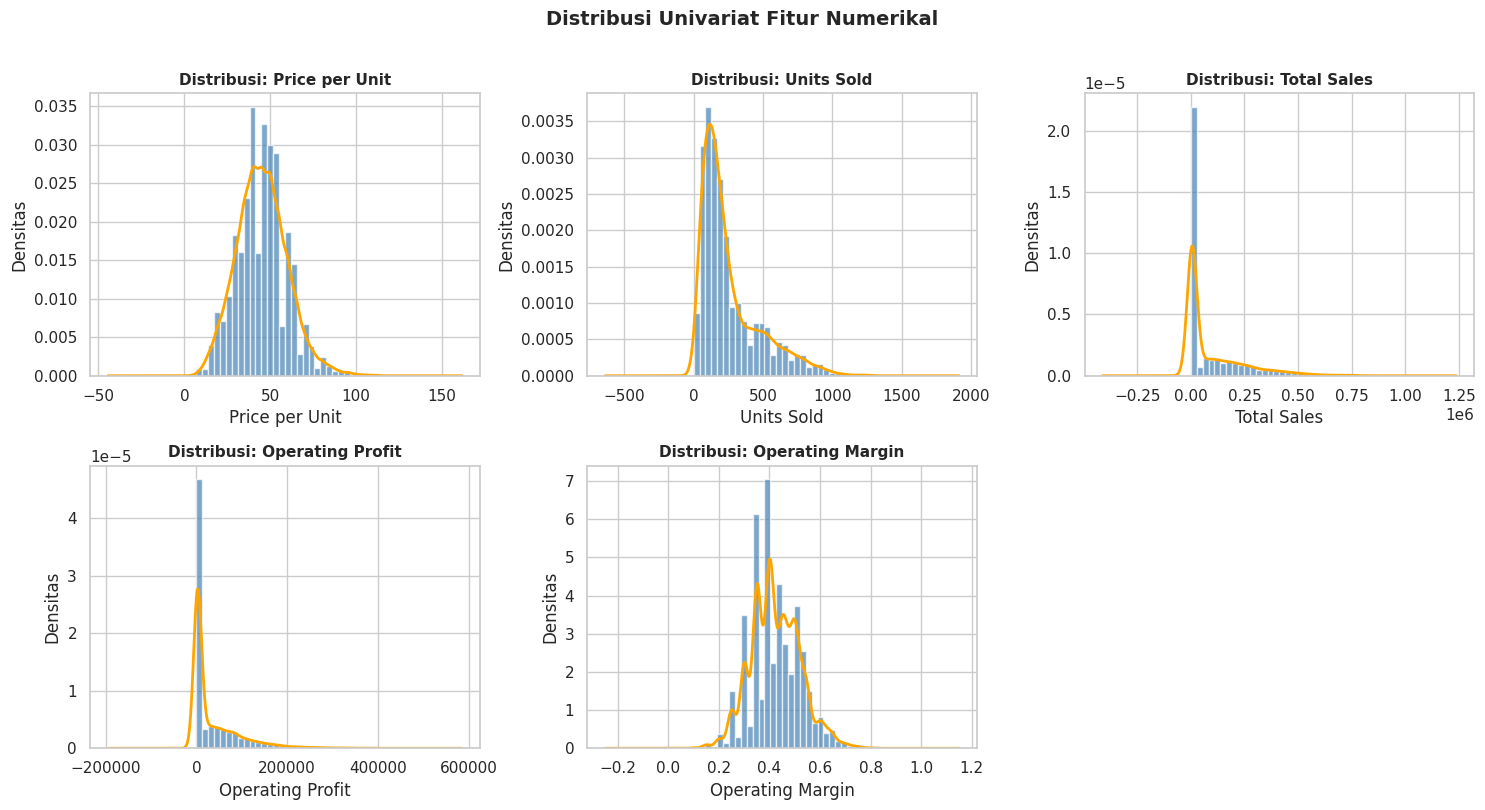

In [ ]:
# ============================================================
# 13. CEK DISTRIBUSI — Univariat, Bivariat, Multivariat
# ============================================================

# --- UNIVARIAT: Histogram + KDE setiap fitur numerik ---
print("📊 Distribusi Univariat — Histogram + KDE")
# 🔧 SESUAIKAN: ubah kolom_numerik jika ingin subset tertentu
cols_plot = [c for c in kolom_numerik if c != 'id']  # exclude ID
n_cols = 3
n_rows = (len(cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    data_clean = df[col].dropna()
    axes[i].hist(data_clean, bins=30, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    data_clean.plot(kind='kde', ax=axes[i], color='orange', lw=2)
    axes[i].set_title(f'Distribusi: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densitas')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Univariat Fitur Numerikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 13B. CEK DISTRIBUSI — Uji Normalitas Statistik
# ============================================================

print("H0: Data berdistribusi normal")
print("p-value > 0.05  → Gagal tolak H0 (distribusi NORMAL)")
print("p-value ≤ 0.05  → Tolak H0 (distribusi TIDAK NORMAL)")

# 🔧 SESUAIKAN: pilih kolom yang ingin diuji normalitasnya
cols_uji = [c for c in kolom_numerik if c not in ['id', 'default']]

hasil_normalitas = []
for col in cols_uji:
    data_clean = df[col].dropna()
    # Shapiro-Wilk (terbaik untuk n < 5000)
    if len(data_clean) <= 5000:
        stat_sw, p_sw = shapiro(data_clean[:5000])
    else:
        stat_sw, p_sw = shapiro(data_clean.sample(5000, random_state=42))
    # Kolmogorov-Smirnov
    stat_ks, p_ks = kstest(data_clean, 'norm',
                           args=(data_clean.mean(), data_clean.std()))
    # D'Agostino
    stat_da, p_da = normaltest(data_clean)

    hasil_normalitas.append({
        'Fitur'           : col,
        'Shapiro-Wilk p'  : round(p_sw, 4),
        'KS p'            : round(p_ks, 4),
        "D'Agostino p"    : round(p_da, 4),
        'Normal?'         : '✅ Ya' if (p_sw > 0.05 and p_ks > 0.05) else '❌ Tidak'
    })

display(pd.DataFrame(hasil_normalitas))

H0: Data berdistribusi normal
p-value > 0.05  → Gagal tolak H0 (distribusi NORMAL)
p-value ≤ 0.05  → Tolak H0 (distribusi TIDAK NORMAL)


,Fitur,Shapiro-Wilk p,KS p,D'Agostino p,Normal?
0,Price per Unit,0.0000,0.0000,0.0000,❌ Tidak
1,Units Sold,0.0000,0.0000,0.0000,❌ Tidak
2,Total Sales,0.0000,0.0000,0.0000,❌ Tidak
3,Operating Profit,0.0000,0.0000,0.0000,❌ Tidak
4,Operating Margin,0.0000,0.0000,0.0000,❌ Tidak


📊 Visualisasi Distribusi Miring vs Normal


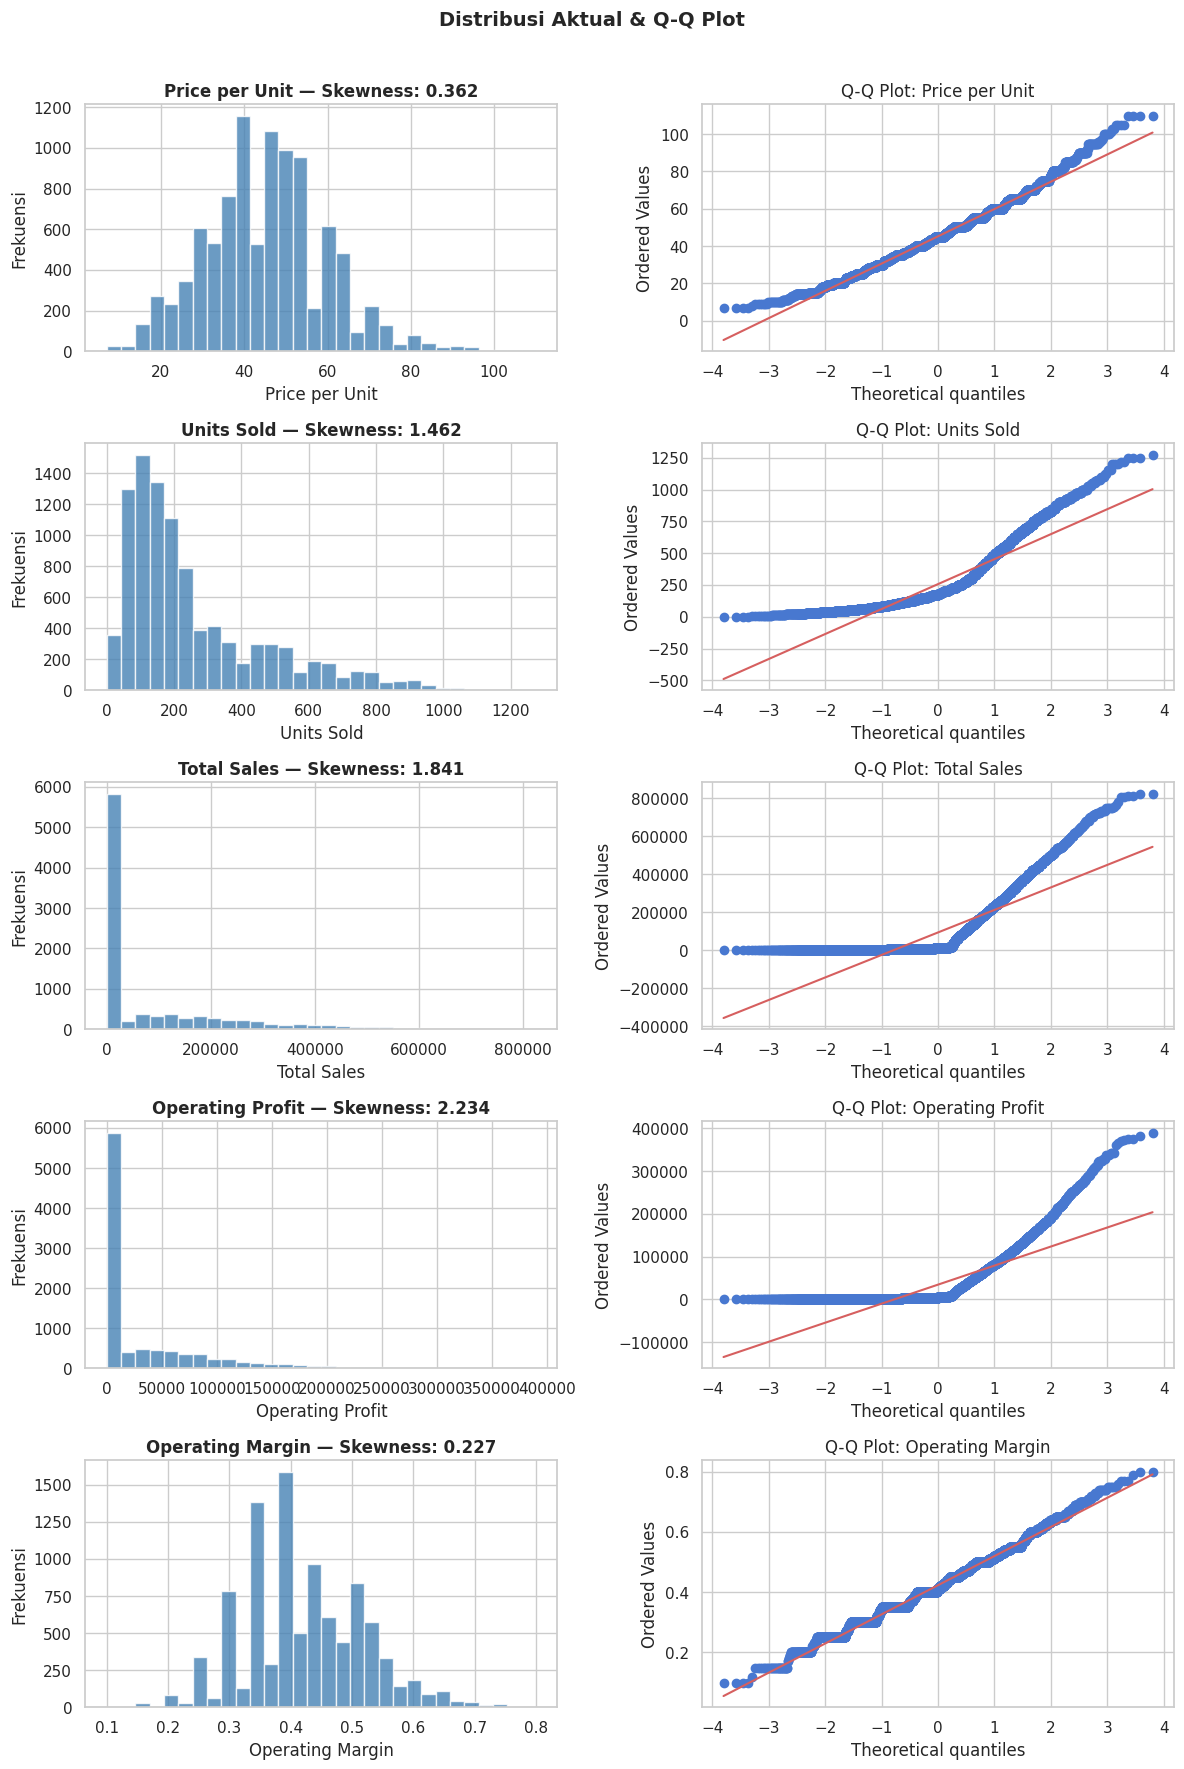

In [ ]:
# ============================================================
# 14. CEK DISTRIBUSI MIRING (Skewed Distribution)
# ============================================================
print("📊 Visualisasi Distribusi Miring vs Normal")
# 🔧 SESUAIKAN: kolom yang ingin dilihat distribusinya
cols_skew_check = [c for c in kolom_numerik if c not in ['id', 'default']]

fig, axes = plt.subplots(len(cols_skew_check), 2,
                          figsize=(12, len(cols_skew_check) * 3.5))
if len(cols_skew_check) == 1:
    axes = [axes]

for i, col in enumerate(cols_skew_check):
    data_clean = df[col].dropna()
    sk = data_clean.skew()
    # Histogram aktual
    axes[i][0].hist(data_clean, bins=30, color='steelblue',
                    edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{col} — Skewness: {sk:.3f}', fontweight='bold')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frekuensi')
    # Q-Q Plot
    stats.probplot(data_clean, dist="norm", plot=axes[i][1])
    axes[i][1].set_title(f'Q-Q Plot: {col}')

plt.suptitle('Distribusi Aktual & Q-Q Plot', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 15. CEK DATA KOSONG — Ringkasan
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Kosong': missing,
}).sort_values('Jumlah Kosong', ascending=False)

display(missing_df)

# Heatmap missing values
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='Reds',
                yticklabels=False, linewidths=0.5)
    plt.title('Peta Lokasi Data Kosong', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Tidak ada data kosong!")

,Jumlah Kosong
Retailer,0
Transaction ID,0
Invoice Date,0
Region,0
State,0
City,0
Product,0
Product ID,0
Price per Unit,0
Units Sold,0


✅ Tidak ada data kosong!


In [ ]:
# ============================================================
# 16. LOKASI DATA KOSONG — Index Baris
# ============================================================

kolom_kosong = df.columns[df.isnull().any()].tolist()
if kolom_kosong:
    for col in kolom_kosong:
        idx_kosong = df[df[col].isnull()].index.tolist()
        print(f"📌 Kolom '{col}' — {len(idx_kosong)} data kosong")
        print(f"   Index baris: {idx_kosong}")
        display(df.loc[idx_kosong, :].head(10))  # tampilkan maks 10 baris
else:
    print("✅ Tidak ada data kosong di seluruh kolom.")

✅ Tidak ada data kosong di seluruh kolom.


In [ ]:
# ============================================================
# 17. CEK DATA DUPLIKAT — Ringkasan
# ============================================================

jml_duplikat = df.duplicated().sum()
pct_duplikat = jml_duplikat / len(df) * 100
print(f"Jumlah baris duplikat : {jml_duplikat:,}")
print(f"Persentase            : {pct_duplikat:.2f}%")
print(f"Status                : {'⚠️ Ada duplikat!' if jml_duplikat > 0 else '✅ Tidak ada duplikat'}")

Jumlah baris duplikat : 0
Persentase            : 0.00%
Status                : ✅ Tidak ada duplikat


In [ ]:
# ============================================================
# 18. LOKASI DATA DUPLIKAT — Index Baris
# ============================================================

duplikat_mask = df.duplicated(keep='first')
idx_duplikat = df[duplikat_mask].index.tolist()

if idx_duplikat:
    print(f"Index baris duplikat (yang ke-2 dst): {idx_duplikat}")
    print("\\nBaris duplikat tersebut:")
    display(df.loc[idx_duplikat])
else:
    print("✅ Tidak ada data duplikat.")

✅ Tidak ada data duplikat.


In [ ]:
# ============================================================
# 19. PENYESUAIAN TIPE DATA
# ============================================================
print("Tipe data sebelum penyesuaian:")
print(df.dtypes)
print()

# Normalize column names by stripping whitespace
df.columns = df.columns.str.strip()
print("✅ Nama kolom dinormalisasi (whitespace dihilangkan).")

# --- Float ke Integer ---
# 🔧 SESUAIKAN: daftar kolom float yang seharusnya integer (tidak ada desimal)
# Contoh: kolom 'tanggungan' seharusnya int
# kolom_float_ke_int = ['tanggungan', 'default']  # 🔧 SESUAIKAN
# for col in kolom_float_ke_int:
#     if col in df.columns:
#         df[col] = df[col].fillna(0).astype(int)
#         print(f"✅ '{col}': float → int")

# --- Object ke Numeric ---
# 🔧 SESUAIKAN: kolom string berisi angka
kolom_str_ke_num = ['Price per Unit', 'Operating Profit', 'Operating Margin']  # 🔧 SESUAIKAN (perhatikan 'Price per Unit' tanpa spasi depan)
for col in kolom_str_ke_num:
    if col in df.columns:
        # Remove '$' and replace ',' with '.' then strip whitespace
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '.', regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')  # 'coerce' → NaN jika gagal
        print(f"✅ '{col}': object → numeric")

# --- Object/String ke Datetime ---
# 🔧 SESUAIKAN: kolom tanggal
kolom_datetime = ['Invoice Date']  # 🔧 SESUAIKAN
for col in kolom_datetime:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce',
                                  infer_datetime_format=True)
        print(f"✅ '{col}': object → datetime")

# --- Integer ke Float (jika ada nilai desimal) ---
# kolom_int_ke_float = ['nilai_x']  # 🔧 SESUAIKAN
# df['nilai_x'] = df['nilai_x'].astype(float)

# --- Object/String ke Time ---
kolom_time = ['timestamp']  # 🔧 Sesuaikan nama kolom

for col in kolom_time:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], format='%H:%M:%S', errors='coerce').dt.time
        print(f"✅ '{col}': object → time")
        print(f"{df[col].dropna().head(3).tolist()}")

print("Tipe data setelah penyesuaian:")
print(df.dtypes)

Tipe data sebelum penyesuaian:
Retailer                    object
Transaction ID              object
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Product ID                  object
Price per Unit             float64
Units Sold                   int64
Total Sales                  int64
Operating Profit           float64
Operating Margin           float64
Sales Method                object
dtype: object

✅ Nama kolom dinormalisasi (whitespace dihilangkan).
✅ 'Price per Unit': object → numeric
✅ 'Operating Profit': object → numeric
✅ 'Operating Margin': object → numeric
Tipe data setelah penyesuaian:
Retailer                    object
Transaction ID              object
Invoice Date        datetime64[ns]
Region                      object
State                       object
City                        object
Product                     object
Product ID          

In [ ]:
# ============================================================
# 20. PERIKSA TIPE DATA SPESIFIK — .dtypes
# ============================================================

# Cek satu kolom
print("Tipe data per kolom individual:")
print(f"  'Total Sales'    : {df['Total Sales'].dtype}") # 🔧 SESUAIKAN
print(f"  'Product'        : {df['Product'].dtype}")   # 🔧 SESUAIKAN
print(f"  'Invoice Date'   : {df['Invoice Date'].dtype}")    # 🔧 SESUAIKAN

# Cek beberapa kolom sekaligus
kolom_cek = ['Retailer', 'Region', 'Sales Method']  # 🔧 SESUAIKAN
print("Tipe data beberapa kolom sekaligus:")
print(df[kolom_cek].dtypes)

# Kelompokkan per tipe
print("Ringkasan per tipe data:")
for dtype, cols in df.dtypes.groupby(df.dtypes):
    print(f"  {str(dtype):15s}: {list(cols.index)}")

Tipe data per kolom individual:
  'Total Sales'    : int64
  'Product'        : object
  'Invoice Date'   : datetime64[ns]
Tipe data beberapa kolom sekaligus:
Retailer        object
Region          object
Sales Method    object
dtype: object
Ringkasan per tipe data:
  datetime64[ns] : ['Invoice Date']
  int64          : ['Units Sold', 'Total Sales']
  float64        : ['Price per Unit', 'Operating Profit', 'Operating Margin']
  object         : ['Retailer', 'Transaction ID', 'Region', 'State', 'City', 'Product', 'Product ID', 'Sales Method']


In [ ]:
# ============================================================
# 21. KONSISTENSI FORMAT KOLOM TANGGAL
# ============================================================

KOLOM_TANGGAL = 'Invoice Date'  # 🔧 SESUAIKAN

if KOLOM_TANGGAL in df.columns:
    print(f"Kolom '{KOLOM_TANGGAL}':")
    print(f"  Tipe data    : {df[KOLOM_TANGGAL].dtype}")
    print(f"  Contoh nilai : {df[KOLOM_TANGGAL].dropna().head(5).tolist()}")
    print(f"  Nilai kosong : {df[KOLOM_TANGGAL].isnull().sum()}")
    print(f"  Rentang      : {df[KOLOM_TANGGAL].min()} s.d. {df[KOLOM_TANGGAL].max()}")

    # Ekstraksi komponen tanggal
    # 🔧 Aktifkan sesuai kebutuhan
    df['tahun']  = df[KOLOM_TANGGAL].dt.year
    df['bulan']  = df[KOLOM_TANGGAL].dt.month
    df['hari']   = df[KOLOM_TANGGAL].dt.day
    df['hari_minggu'] = df[KOLOM_TANGGAL].dt.dayofweek # 0=Senin
    df['kuartal']     = df[KOLOM_TANGGAL].dt.quarter
    print("\n✅ Komponen tanggal (tahun, bulan, hari) berhasil diekstrak.")

# ============================================================
# TROUBLESHOOT FORMAT TANGGAL — Panduan
print("""
╔══════════════════════════════════════════════════════════╗
║         TROUBLESHOOT FORMAT TANGGAL UMUM                ║
╒═══════════════════════════════════════════════════════════╗
║ Masalah 1: Format campuran (DD/MM/YYYY vs MM/DD/YYYY)   ║
║   Solusi : pd.to_datetime(df[col], dayfirst=True)       ║
║                                                          ║
║ Masalah 2: Format tidak standar misal '25-Jan-2023'     ║
║   Solusi : pd.to_datetime(df[col], format='%d-%b-%Y')   ║
║                                                          ║
║ Masalah 3: Epoch timestamp (angka unix)                  ║
║   Solusi : pd.to_datetime(df[col], unit='s')            ║
║                                                          ║
║ Masalah 4: Kolom tanggal + waktu pisah                  ║
║   Solusi : pd.to_datetime(df['tgl']+' '+df['jam'])      ║
║                                                          ║
║ Masalah 5: Nilai NaT setelah konversi                   ║
║   Solusi : df[col].isnull().sum() → cek errors='coerce' ║
║            Periksa baris bermasalah:                    ║
║            df[df[col].isnull() & df[col+'_ori'].notna()]║
╚═══════════════════════════════════════════════════════════╝
""")

Kolom 'Invoice Date':
  Tipe data    : datetime64[ns]
  Contoh nilai : [Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-01 00:00:00')]
  Nilai kosong : 5583
  Rentang      : 2020-01-01 00:00:00 s.d. 2021-12-12 00:00:00

✅ Komponen tanggal (tahun, bulan, hari) berhasil diekstrak.

╔══════════════════════════════════════════════════════════╗
║         TROUBLESHOOT FORMAT TANGGAL UMUM                ║
╒═══════════════════════════════════════════════════════════╗
║ Masalah 1: Format campuran (DD/MM/YYYY vs MM/DD/YYYY)   ║
║   Solusi : pd.to_datetime(df[col], dayfirst=True)       ║
║                                                          ║
║ Masalah 2: Format tidak standar misal '25-Jan-2023'     ║
║   Solusi : pd.to_datetime(df[col], format='%d-%b-%Y')   ║
║                                                          ║
║ Masalah 3: Epoch timestamp (angka unix)                  ║
║   So

In [ ]:
# ============================================================
# 22. IMPUTASI DATA KOSONG & MANIPULASI INDEX TERTENTU
# ============================================================

# # --- Metode 1: Isi data kosong di kolom numerik dengan MEDIAN ---
# kolom_imputasi_median = ['pendapatan', 'skor_kredit']  # 🔧 SESUAIKAN
# for col in kolom_imputasi_median:
#     if col in df.columns:
#         median_val = df[col].median()
#         jumlah_diisi = df[col].isnull().sum()
#         df[col].fillna(median_val, inplace=True)
#         print(f"✅ '{col}': {jumlah_diisi} nilai kosong diisi dengan median = {median_val:.2f}")

## --- Metode 2: Isi data kosong kategorikal dengan MODUS ---
# kolom_imputasi_modus = ['kategori']  # 🔧 SESUAIKAN
# for col in kolom_imputasi_modus:
#     if col in df.columns:
#         modus_val = df[col].mode()[0]
#         jumlah_diisi = df[col].isnull().sum()
#         df[col].fillna(modus_val, inplace=True)
#         print(f"✅ '{col}': {jumlah_diisi} nilai kosong diisi dengan modus = '{modus_val}'")

## --- Metode 3: Isi data kosong dengan nilai tertentu di index spesifik ---
# df.at[10, 'pendapatan'] = 4500.0     # 🔧 SESUAIKAN nomor index dan nilai manual
# df.at[50, 'kategori']   = 'A'

## --- Metode 4: Isi forward/backward fill (untuk data time series) ---
# df['kolom'] = df['kolom'].fillna(method='ffill')  # isi ke depan
# df['kolom'] = df['kolom'].fillna(method='bfill')  # isi ke belakang

## --- Metode 5: Koreksi nilai invalid di index tertentu ---
# idx_invalid = df[df['usia'] < 0].index.tolist() # 🔧 SESUAIKAN: misalnya usia negatif atau > 120
# if idx_invalid:
#     print(f"⚠️ Ditemukan usia negatif di index: {idx_invalid}")
#     df.loc[idx_invalid, 'usia'] = df['usia'].median()
#     print(f"✅ Diisi dengan median usia = {df['usia'].median():.0f}")

print("Verifikasi missing values setelah imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("✅ Imputasi selesai!" if df.isnull().sum().sum() == 0 else "⚠️ Masih ada nilai kosong.")

Verifikasi missing values setelah imputasi:
Series([], dtype: int64)
✅ Imputasi selesai!


In [ ]:
# ============================================================
# 23. DETEKSI OUTLIER — IQR & Z-SCORE
# ============================================================

cols_outlier = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']] # ❦ SESUAIKAN: kolom numerik untuk dicek outlier
#cols_outlier = ['pendapatan', 'nilai_pinjaman']

for col in cols_outlier:
    data = df[col].dropna()

    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR

    mask_outlier = (df[col] < batas_bawah) | (df[col] > batas_atas)
    df_outlier   = df[mask_outlier][[col]].copy()  # ✅ tanpa tanda kutip
    df_outlier['status'] = df_outlier[col].apply(
        lambda x: '⬆️ Atas' if x > batas_atas else '⬇️ Bawah'
    )

    print(f"📌 '{col}'")
    print(f"   Batas bawah : {batas_bawah:.2f}  |  Batas atas : {batas_atas:.2f}")
    print(f"   Jumlah outlier: {mask_outlier.sum()}")

    if mask_outlier.sum() > 0:
        print(f"   Index & nilai outlier:")
        display(df_outlier)
    else:
        print("   ✅ Tidak ada outlier.")

# Ringkasan tabel IQR + Z-Score
hasil_outlier = []
for col in cols_outlier:
    data = df[col].dropna()

    # Metode IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outlier_iqr = ((data < batas_bawah) | (data > batas_atas)).sum()

    # Metode Z-Score
    z_scores    = np.abs(stats.zscore(data))
    outlier_z   = (z_scores > 3).sum()

    hasil_outlier.append({
        'Fitur'              : col,
        'Q1'                 : round(Q1, 2),
        'Q3'                 : round(Q3, 2),
        'IQR'                : round(IQR, 2),
        'Batas Bawah (IQR)'  : round(batas_bawah, 2),
        'Batas Atas (IQR)'   : round(batas_atas, 2),
        'Outlier IQR'        : outlier_iqr,
        'Outlier Z-Score'    : outlier_z,
    })

outlier_df = pd.DataFrame(hasil_outlier)
display(outlier_df)

print("Keterangan:")
print("  IQR   : data di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] dianggap outlier")
print("  Z-Score: |z| > 3 dianggap outlier")

📌 'tahun'
   Batas bawah : 2021.00  |  Batas atas : 2021.00
   Jumlah outlier: 521
   Index & nilai outlier:


,tahun,status
0,2020.0000,⬇️ Bawah
1,2020.0000,⬇️ Bawah
2,2020.0000,⬇️ Bawah
3,2020.0000,⬇️ Bawah
4,2020.0000,⬇️ Bawah
...,...,...
1229,2020.0000,⬇️ Bawah
1230,2020.0000,⬇️ Bawah
1231,2020.0000,⬇️ Bawah
1232,2020.0000,⬇️ Bawah


📌 'bulan'
   Batas bawah : 7.50  |  Batas atas : 11.50
   Jumlah outlier: 2352
   Index & nilai outlier:


,bulan,status
0,1.0000,⬇️ Bawah
1,1.0000,⬇️ Bawah
2,1.0000,⬇️ Bawah
3,1.0000,⬇️ Bawah
4,1.0000,⬇️ Bawah
...,...,...
9276,12.0000,⬆️ Atas
9277,12.0000,⬆️ Atas
9278,12.0000,⬆️ Atas
9279,12.0000,⬆️ Atas


📌 'hari'
   Batas bawah : 0.00  |  Batas atas : 8.00
   Jumlah outlier: 1358
   Index & nilai outlier:


...

,hari_minggu,status
0,2.0000,⬇️ Bawah
1,2.0000,⬇️ Bawah
2,2.0000,⬇️ Bawah
3,2.0000,⬇️ Bawah
4,2.0000,⬇️ Bawah
...,...,...
9276,6.0000,⬆️ Atas
9277,6.0000,⬆️ Atas
9278,6.0000,⬆️ Atas
9279,6.0000,⬆️ Atas


📌 'kuartal'
   Batas bawah : 1.50  |  Batas atas : 5.50
   Jumlah outlier: 600
   Index & nilai outlier:


,kuartal,status
0,1.0000,⬇️ Bawah
1,1.0000,⬇️ Bawah
2,1.0000,⬇️ Bawah
3,1.0000,⬇️ Bawah
4,1.0000,⬇️ Bawah
...,...,...
9027,1.0000,⬇️ Bawah
9028,1.0000,⬇️ Bawah
9029,1.0000,⬇️ Bawah
9030,1.0000,⬇️ Bawah


,Fitur,Q1,Q3,IQR,Batas Bawah (IQR),Batas Atas (IQR),Outlier IQR,Outlier Z-Score
0,tahun,2021.0000,2021.0000,0.0000,2021.0000,2021.0000,521,521
1,bulan,9.0000,10.0000,1.0000,7.5000,11.5000,2352,97
2,hari,3.0000,5.0000,2.0000,0.0000,8.0000,1358,0
3,hari_minggu,4.0000,4.0000,0.0000,4.0000,4.0000,3387,0
4,kuartal,3.0000,4.0000,1.0000,1.5000,5.5000,600,0


Keterangan:
  IQR   : data di luar [Q1 - 1.5*IQR, Q3 + 1.5*IQR] dianggap outlier
  Z-Score: |z| > 3 dianggap outlier


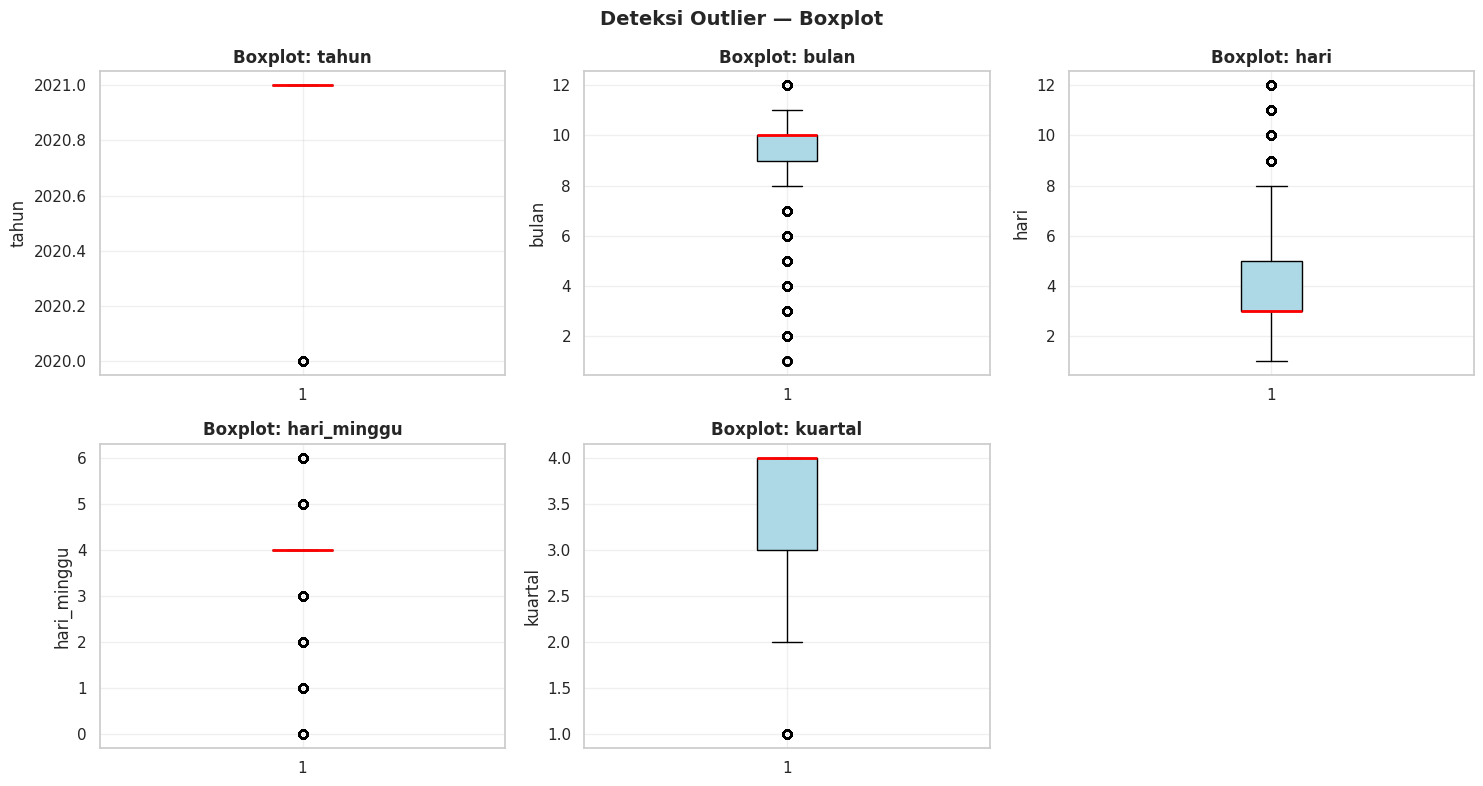

In [ ]:
# ============================================================
# 24. VISUALISASI OUTLIER — Boxplot
# ============================================================
# 🔧 SESUAIKAN: ubah cols_outlier jika ingin subset
n_cols = 3
n_rows = (len(cols_outlier) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_outlier):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
                          medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('lightblue')
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier — Boxplot', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 25. PENANGANAN OUTLIER
# ============================================================

# Memilih kolom yang akan ditangani outliernya berdasarkan hasil analisis skewness dan kurtosis
# Kolom seperti 'Units Sold', 'Total Sales', 'Operating Profit' seringkali memiliki outlier yang signifikan.
# Kolom komponen tanggal (tahun, bulan, hari, dll.) dikecualikan karena 'outlier' di sana cenderung
# merepresentasikan batas-batas distribusi diskrit yang valid, bukan kesalahan data.
COLS_HANDLE_OUTLIER = ['Units Sold', 'Total Sales', 'Operating Profit']  # ❦ SESUAIKAN kolom yang ingin ditangani outliernya

## ===== OPSI A: HAPUS baris yang mengandung outlier (IQR) =====
# idx_to_drop = set()
# for col in COLS_HANDLE_OUTLIER:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
#     idx_to_drop.update(df[mask].index.tolist())
# print(f"Akan dihapus {len(idx_to_drop)} baris outlier")
# df = df.drop(index=list(idx_to_drop)).reset_index(drop=True)
# print(f"✅ Dimensi setelah hapus outlier: {df.shape}")

## ===== OPSI B: WINSORIZING — ganti outlier dengan batas IQR =====
# Winsorizing adalah metode yang lebih aman daripada menghapus baris, karena mempertahankan ukuran dataset.
for col in COLS_HANDLE_OUTLIER:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = ((df[col] < lower) | (df[col] > upper)).sum()
        if before > 0:
            df[col] = df[col].clip(lower=lower, upper=upper)
            print(f"✅ '{col}': {before} outlier di-winsorize ke [{lower:.2f}, {upper:.2f}]")
        else:
            print(f"ℹ️ '{col}': Tidak ada outlier yang perlu di-winsorize.")

## ===== OPSI C: TRANSFORMASI LOG (untuk distribusi sangat miring) =====
# df['pendapatan_log'] = np.log1p(df['pendapatan'])  # log(1+x) aman untuk 0
# print("✅ Kolom 'pendapatan_log' berhasil dibuat (log transform)")

print("✅ Penanganan outlier selesai!")
print(f"Dimensi dataset saat ini: {df.shape}")

ℹ️ 'Units Sold': Tidak ada outlier yang perlu di-winsorize.
ℹ️ 'Total Sales': Tidak ada outlier yang perlu di-winsorize.
ℹ️ 'Operating Profit': Tidak ada outlier yang perlu di-winsorize.
✅ Penanganan outlier selesai!
Dimensi dataset saat ini: (9648, 19)


In [ ]:
# ============================================================
# 26. CORRELATION ANALYSIS — Pearson, Spearman, Kendall
# ============================================================

# 🔧 SESUAIKAN: kolom numerik untuk korelasi
cols_corr = [c for c in df.select_dtypes(include=np.number).columns
             if c not in ['id', 'tahun', 'bulan', 'hari']]

print("--- Pearson (asumsi distribusi normal, data kontinu) ---")
corr_pearson = df[cols_corr].corr(method='pearson')
display(corr_pearson.round(3))

print("--- Spearman (data ordinal / tidak normal) ---")
corr_spearman = df[cols_corr].corr(method='spearman')
display(corr_spearman.round(3))

print("--- Kendall (data kecil / banyak ties) ---")
corr_kendall = df[cols_corr].corr(method='kendall')
display(corr_kendall.round(3))

--- Pearson (asumsi distribusi normal, data kontinu) ---


,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,hari_minggu,kuartal
Price per Unit,1.0000,0.2700,0.4090,0.3810,-0.1370,0.0440,0.0480
Units Sold,0.2700,1.0000,0.9200,0.9150,-0.3240,-0.0300,-0.0500
Total Sales,0.4090,0.9200,1.0000,0.9790,-0.3940,-0.0120,-0.0240
Operating Profit,0.3810,0.9150,0.9790,1.0000,-0.3010,-0.0110,-0.0280
Operating Margin,-0.1370,-0.3240,-0.3940,-0.3010,1.0000,-0.0190,-0.0340
hari_minggu,0.0440,-0.0300,-0.0120,-0.0110,-0.0190,1.0000,0.2360
kuartal,0.0480,-0.0500,-0.0240,-0.0280,-0.0340,0.2360,1.0000


--- Spearman (data ordinal / tidak normal) ---


,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,hari_minggu,kuartal
Price per Unit,1.0000,0.2580,0.4730,0.4540,-0.1310,0.0490,0.0420
Units Sold,0.2580,1.0000,0.9220,0.9130,-0.3550,-0.0200,-0.0390
Total Sales,0.4730,0.9220,1.0000,0.9880,-0.4440,-0.0060,-0.0280
Operating Profit,0.4540,0.9130,0.9880,1.0000,-0.3300,-0.0090,-0.0330
Operating Margin,-0.1310,-0.3550,-0.4440,-0.3300,1.0000,-0.0170,-0.0270
hari_minggu,0.0490,-0.0200,-0.0060,-0.0090,-0.0170,1.0000,0.1980
kuartal,0.0420,-0.0390,-0.0280,-0.0330,-0.0270,0.1980,1.0000


--- Kendall (data kecil / banyak ties) ---


,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,hari_minggu,kuartal
Price per Unit,1.0000,0.1760,0.3370,0.3200,-0.0910,0.0370,0.0340
Units Sold,0.1760,1.0000,0.7720,0.7550,-0.2400,-0.0150,-0.0310
Total Sales,0.3370,0.7720,1.0000,0.9130,-0.3000,-0.0040,-0.0220
Operating Profit,0.3200,0.7550,0.9130,1.0000,-0.2090,-0.0070,-0.0260
Operating Margin,-0.0910,-0.2400,-0.3000,-0.2090,1.0000,-0.0130,-0.0220
hari_minggu,0.0370,-0.0150,-0.0040,-0.0070,-0.0130,1.0000,0.1750
kuartal,0.0340,-0.0310,-0.0220,-0.0260,-0.0220,0.1750,1.0000


Interpretasi Koefisien Korelasi:
> |r| = 0.00–0.19 : Sangat lemah / Tidak ada korelasi

> |r| = 0.20–0.39 : Lemah

> |r| = 0.40–0.59 : Sedang

>|r| = 0.60–0.79 : Kuat

> |r| = 0.80–1.00 : Sangat kuat

> r > 0 : Korelasi positif (searah)

> r < 0 : Korelasi negatif (berlawanan arah)

📊 Crosstab: 'Retailer' × 'Sales Method'


Sales Method,In-store,Online,Outlet,Total
Retailer,,,,
Amazon,118,540,291,949
Foot Locker,449,1395,793,2637
Kohl's,144,576,310,1030
Sports Direct,293,995,744,2032
Walmart,37,288,301,626
West Gear,699,1095,580,2374
Total,1740,4889,3019,9648


  Persentase baris (%):


Sales Method,In-store,Online,Outlet
Retailer,,,
Amazon,12.4000,56.9000,30.7000
Foot Locker,17.0000,52.9000,30.1000
Kohl's,14.0000,55.9000,30.1000
Sports Direct,14.4000,49.0000,36.6000
Walmart,5.9000,46.0000,48.1000
West Gear,29.4000,46.1000,24.4000


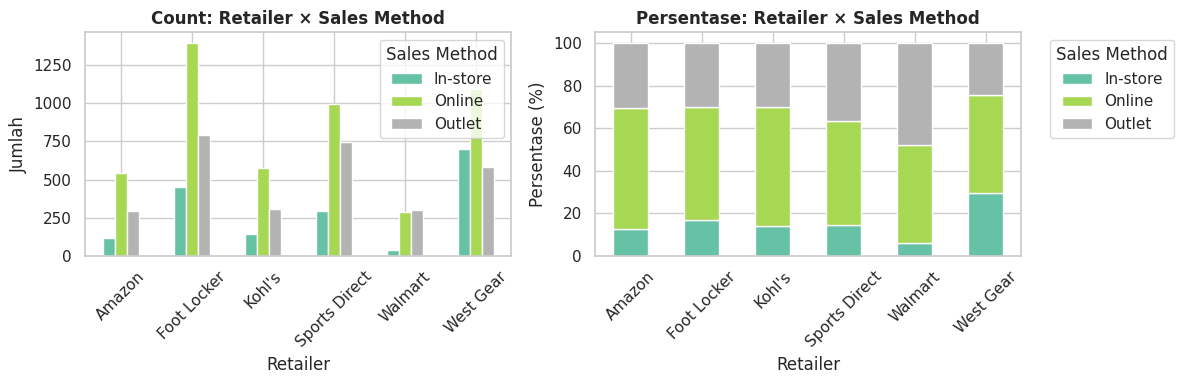

In [ ]:
# ============================================================
# 27. CROSSTAB ANALYSIS — Data Kategorikal
# ============================================================

# 🔧 SESUAIKAN: pasangan kolom kategorikal yang ingin dianalisis
CROSSTAB_PAIRS = [
    ('Retailer', 'Sales Method'),
    # Contoh pasangan lain:
    # ('Region', 'Sales Method'),
    # ('Product', 'Sales Method'),
]

for col_a, col_b in CROSSTAB_PAIRS:
    if col_a in df.columns and col_b in df.columns:
        print(f"📊 Crosstab: '{col_a}' × '{col_b}'")
        ct = pd.crosstab(df[col_a], df[col_b],
                          margins=True, margins_name='Total')
        display(ct)

        ct_pct = pd.crosstab(df[col_a], df[col_b], normalize='index').round(3) * 100
        print(f"  Persentase baris (%):")
        display(ct_pct)

        # Visualisasi
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ct.drop('Total', axis=0).drop('Total', axis=1).plot(
            kind='bar', ax=axes[0], colormap='Set2', rot=45)
        axes[0].set_title(f'Count: {col_a} × {col_b}', fontweight='bold')
        axes[0].set_ylabel('Jumlah')
        axes[0].legend(title=col_b)

        ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='Set2', rot=45)
        axes[1].set_title(f'Persentase: {col_a} × {col_b}', fontweight='bold')
        axes[1].set_ylabel('Persentase (%)')
        axes[1].legend(title=col_b, bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Kolom '{col_a}' atau '{col_b}' tidak ditemukan di dataset.")


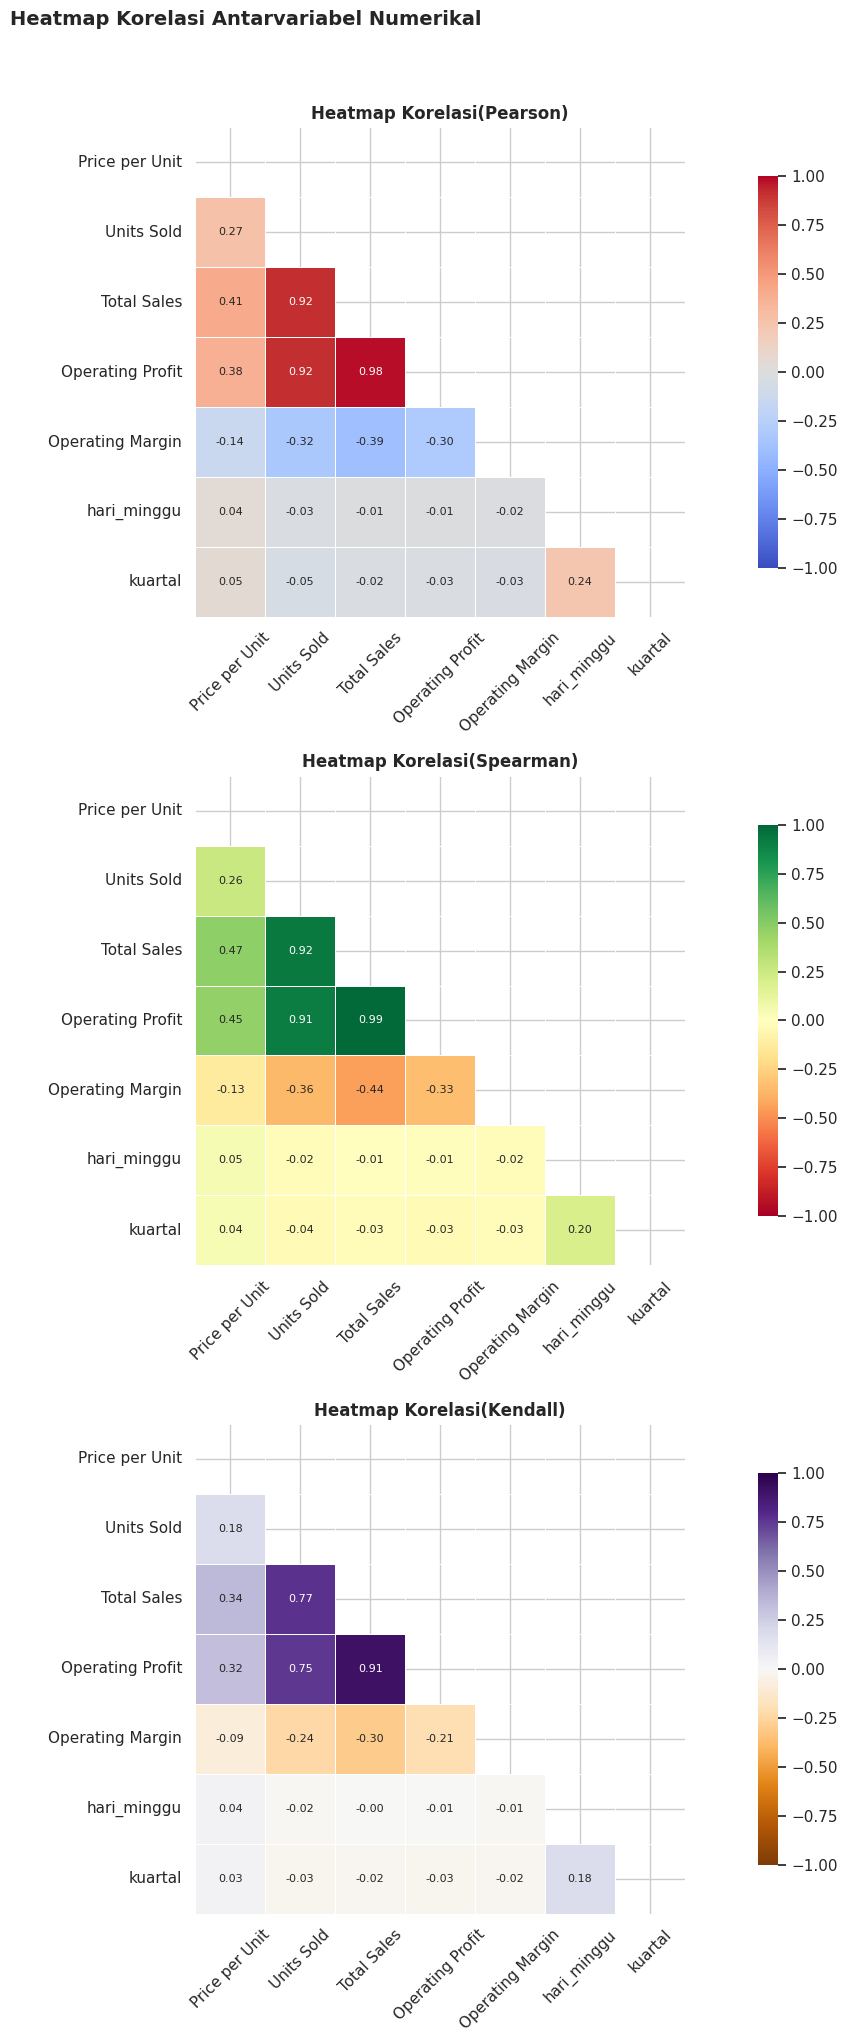

In [ ]:
# ============================================================
# 28. HEATMAP CORRELATION — Data Numerikal
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

metode_list = [
    ('Pearson',  corr_pearson,  'coolwarm'),
    ('Spearman', corr_spearman, 'RdYlGn'),
    ('Kendall',  corr_kendall,  'PuOr'),
]

for ax, (nama, corr_mat, cmap) in zip(axes, metode_list):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))  # Segitiga atas disembunyikan
    sns.heatmap(
        corr_mat,
        ax=ax,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 8}
    )
    ax.set_title(f'Heatmap Korelasi({nama})', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Heatmap Korelasi Antarvariabel Numerikal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

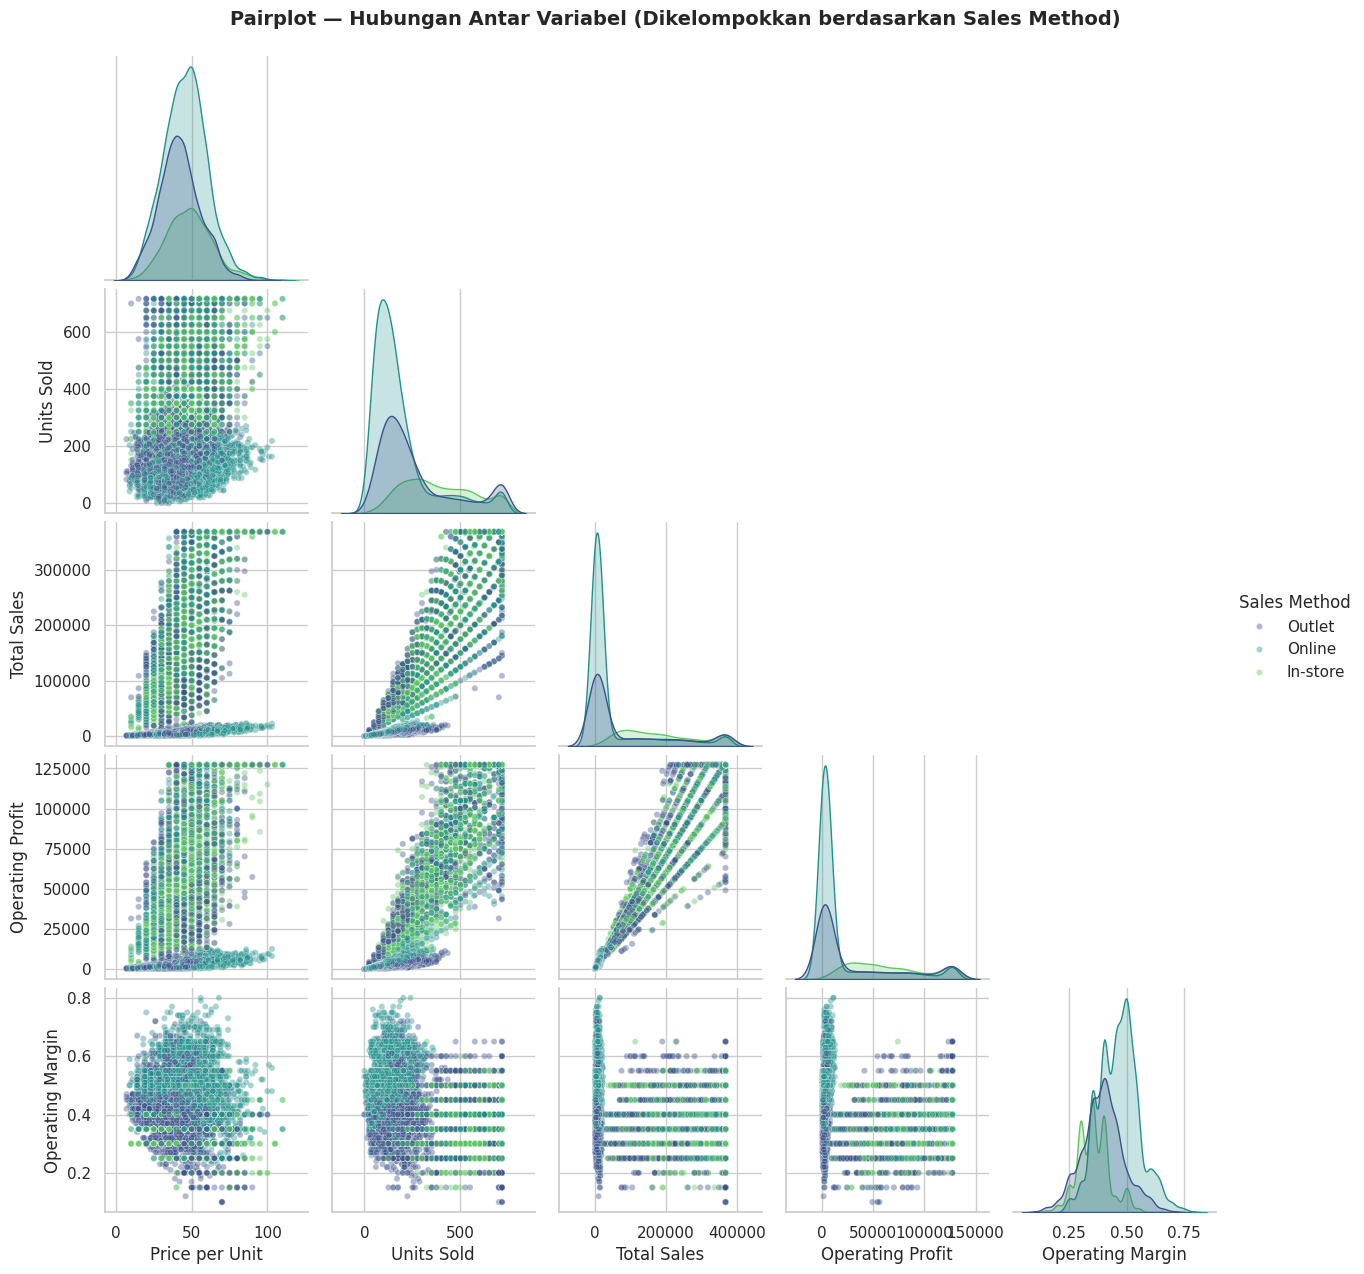

In [ ]:
# ============================================================
# 29. PAIRPLOT — Hubungan Banyak Variabel Sekaligus
# ============================================================

cols_pairplot = [
    'Price per Unit',
    'Units Sold',
    'Total Sales',
    'Operating Profit',
    'Operating Margin'
]  # ❦ SESUAIKAN: kolom numerik untuk pairplot

HUE_COL = 'Sales Method'  # ❦ SESUAIKAN 'hue' untuk pewarnaan berdasarkan kategori (set None jika tidak perlu warna)

df_pair = df[cols_pairplot].copy()
if HUE_COL and HUE_COL in df.columns:
    df_pair[HUE_COL] = df[HUE_COL].astype(str)
    # Pastikan hue column juga ada di df_pair jika ingin digunakan
    if HUE_COL not in df_pair.columns:
        df_pair = pd.concat([df_pair, df[[HUE_COL]]], axis=1)

# Drop NaN values if any, specifically for the columns being plotted and the hue column
df_pair = df_pair.dropna(subset=cols_pairplot + ([HUE_COL] if HUE_COL else [])).reset_index(drop=True)

pairplot = sns.pairplot(
    df_pair,
    hue=HUE_COL,           # ❦ SESUAIKAN
    diag_kind='kde',        # 'hist' atau 'kde'
    plot_kws={'alpha': 0.4, 's': 20},
    corner=True,            # Tampilkan sudut bawah saja
    palette='viridis',       # ❦ SESUAIKAN palette warna
)
pairplot.fig.suptitle('Pairplot — Hubungan Antar Variabel (Dikelompokkan berdasarkan Sales Method)',
                       y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# ============================================================
# 30. ENCODING DATA KATEGORIKAL
# ============================================================

COLS_ENCODE = ['Retailer', 'Region', 'Product', 'Sales Method']  # ♣ SESUAIKAN

df_encoded = df.copy()

## ===== OPSI A: One-Hot Encoding (sklearn) =====
# from sklearn.preprocessing import OneHotEncoder
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# encoded_array = ohe.fit_transform(df_encoded[COLS_ENCODE])
# encoded_cols  = ohe.get_feature_names_out(COLS_ENCODE)
# df_ohe = pd.DataFrame(encoded_array, columns=encoded_cols)
# df_encoded = pd.concat([df_encoded.drop(columns=COLS_ENCODE).reset_index(drop=True),
#                          df_ohe.reset_index(drop=True)], axis=1)
# print("\u2705 One-Hot Encoding (sklearn) selesai")
# print(f"Kolom baru: {list(encoded_cols)}")

## ===== OPSI B: pd.get_dummies (lebih simpel) =====
df_encoded = pd.get_dummies(
    df_encoded,
    columns=COLS_ENCODE,
    prefix=COLS_ENCODE,
    drop_first=True,          # ♣ True = hindari dummy variable trap
    dtype=int
)
print("\u2705 get_dummies selesai")
print(f"Dimensi sebelum : {df.shape}")
print(f"Dimensi sesudah : {df_encoded.shape}")
print("\nKolom baru setelah encoding:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)
display(df_encoded.head(3))

✅ get_dummies selesai
Dimensi sebelum : (9648, 19)
Dimensi sesudah : (9648, 31)

Kolom baru setelah encoding:
['Retailer_Foot Locker', "Retailer_Kohl's", 'Retailer_Sports Direct', 'Retailer_Walmart', 'Retailer_West Gear', 'Region_Northeast', 'Region_South', 'Region_Southeast', 'Region_West', "Product_Men's Athletic Footwear", "Product_Men's Street Footwear", "Product_Women's Apparel", "Product_Women's Athletic Footwear", "Product_Women's Street Footwear", 'Sales Method_Online', 'Sales Method_Outlet']


,Transaction ID,Invoice Date,State,City,Product ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,tahun,bulan,hari,hari_minggu,kuartal,Retailer_Foot Locker,Retailer_Kohl's,Retailer_Sports Direct,Retailer_Walmart,Retailer_West Gear,Region_Northeast,Region_South,Region_Southeast,Region_West,Product_Men's Athletic Footwear,Product_Men's Street Footwear,Product_Women's Apparel,Product_Women's Athletic Footwear,Product_Women's Street Footwear,Sales Method_Online,Sales Method_Outlet
0,IT0001,2020-01-01,New York,New York,MSF33,34.0000,384,13056.0000,6789.1200,0.5200,2020.0000,1.0000,1.0000,2.0000,1.0000,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
1,IT0002,2020-01-01,New York,New York,MSF52,47.0000,336,15792.0000,9633.1200,0.6100,2020.0000,1.0000,1.0000,2.0000,1.0000,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0
2,IT0003,2020-01-01,New York,New York,MSF56,50.0000,716,368618.2500,127273.6212,0.5000,2020.0000,1.0000,1.0000,2.0000,1.0000,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0


In [ ]:
# ============================================================
# 31. SCALING DATA NUMERIKAL
# ============================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

COLS_SCALE = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']  # ♣ SESUAIKAN kolom numerik yang perlu di-scale

print("Statistik sebelum scaling:")
display(df_encoded[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])

## ===== OPSI A: StandardScaler (mean=0, std=1) — cocok jika normal =====
# scaler = StandardScaler()

# df_scaled = df_encoded.copy()
# df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

# print("Statistik setelah RobustScaling:")
# display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
# print("✅ Scaling selesai!")

## ===== OPSI B: MinMaxScaler (0–1) — cocok jika tahu batas =====
# scaler = MinMaxScaler()

# df_scaled = df_encoded.copy()
# df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

# print("Statistik setelah RobustScaling:")
# display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
# print("✅ Scaling selesai!")

## ===== OPSI C: RobustScaler (median-based) — cocok jika banyak outlier =====
scaler = RobustScaler()

df_scaled = df_encoded.copy()
df_scaled[COLS_SCALE] = scaler.fit_transform(df_scaled[COLS_SCALE])

print("\nStatistik setelah RobustScaling:")
display(df_scaled[COLS_SCALE].describe().T[['mean', 'std', 'min', 'max']])
print("✅ Scaling selesai!")

Statistik sebelum scaling:


,mean,std,min,max
Price per Unit,45.2166,14.7054,7.0000,110.0000
Units Sold,250.0610,194.9970,0.0000,716.0000
Total Sales,85622.7293,119783.3713,0.0000,368618.2500
Operating Profit,30347.7004,41689.1172,0.0000,127273.6212
Operating Margin,0.4230,0.0972,0.1000,0.8000



Statistik setelah RobustScaling:


,mean,std,min,max
Price per Unit,0.0108,0.7353,-1.9000,3.2500
Units Sold,0.3035,0.7992,-0.7213,2.2131
Total Sales,0.5218,0.8219,-0.0657,2.4635
Operating Profit,0.5181,0.8314,-0.0872,2.4511
Operating Margin,0.0928,0.6943,-2.2143,2.7857


✅ Scaling selesai!


,Fitur,Importance,Rank,Kumulatif (%)
0,Operating Profit,0.9638,1,96.3800
1,Operating Margin,0.0303,2,99.4000
2,Units Sold,0.0031,3,99.7200
3,Price per Unit,0.0026,4,99.9700
4,hari_minggu,0.0000,5,99.9800
5,kuartal,0.0000,6,99.9800
6,Product_Women's Apparel,0.0000,7,99.9800
7,Retailer_Sports Direct,0.0000,8,99.9800
8,Product_Women's Athletic Footwear,0.0000,9,99.9900
9,Retailer_Kohl's,0.0000,10,99.9900


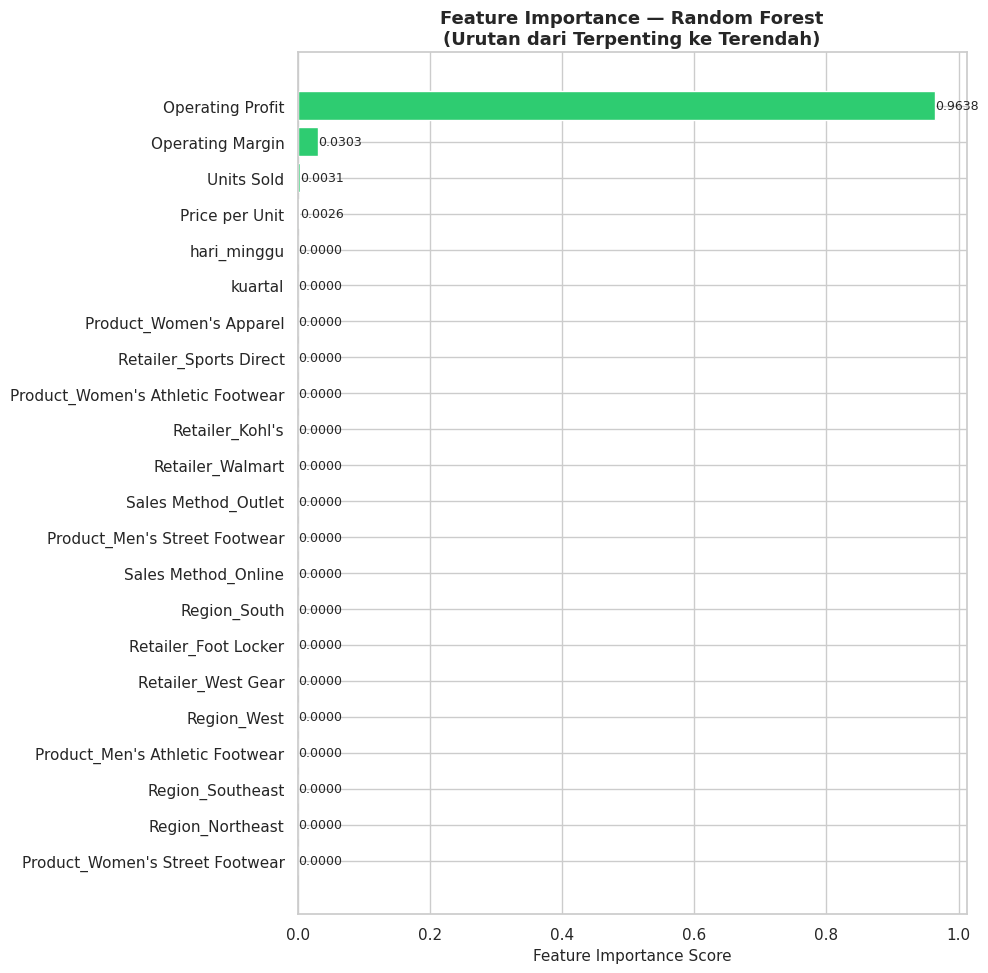

✅ Fitur terpenting hingga terendah telah diurutkan!


In [ ]:
# ============================================================
# 32. FEATURE SELECTION — Urutan Fitur Terpenting
# ============================================================
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

TARGET_COL  = 'Total Sales'      # ♣ SESUAIKAN nama kolom target
TASK_TYPE   = 'regression'  # ♣ SESUAIKAN: 'classification' atau 'regression'

## Siapkan fitur
all_numeric_cols = df_scaled.select_dtypes(include=np.number).columns.tolist()
cols_fs = [c for c in all_numeric_cols
           if c not in [TARGET_COL, 'tahun', 'bulan', 'hari']]

X = df_scaled[cols_fs].fillna(0)  # ♣ SESUAIKAN nama dataframe yang aktif terakhir kali df_encoded atau df jika tidak melalui proses apapun
y = df_scaled[TARGET_COL].fillna(0)


if TASK_TYPE == 'classification':
    # Pastikan y adalah integer untuk klasifikasi
    y = y.astype(int)
    model_fs = RandomForestClassifier(n_estimators=100, random_state=42) # ♣ SESUAIKAN algoritmanya
else:
    model_fs = RandomForestRegressor(n_estimators=100, random_state=42)

model_fs.fit(X, y)

## Buat dataframe importance
importance_df = pd.DataFrame({
    'Fitur'     : cols_fs,
    'Importance': model_fs.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Rank'] = importance_df.index + 1
importance_df['Kumulatif (%)'] = (importance_df['Importance'].cumsum() * 100).round(2)

display(importance_df)

## Visualisasi
plt.figure(figsize=(10, max(4, len(cols_fs) * 0.45)))
colors = ['#2ecc71' if i < 5 else '#3498db' if i < 10 else '#bdc3c7'
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['Fitur'][::-1],
                importance_df['Importance'][::-1],
                color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.title('Feature Importance — Random Forest\n(Urutan dari Terpenting ke Terendah)',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print("\u2705 Fitur terpenting hingga terendah telah diurutkan!")